# Car Model Identifier (Google AI Studio / Gemini)

Upload a photo of a car and Gemini (Google's AI, free via Google AI Studio) will tell you the make, model, approximate year, and how confident it is.

**Setup (one-time, free):**
1. Go to https://aistudio.google.com/apikey and create a free API key (no billing required for the free tier).
2. Set it as an environment variable before launching this notebook, e.g. in your terminal:
   `export GEMINI_API_KEY="AIza..."`
   
   (Or paste it directly into the `api_key=` line in the next cell for quick testing — just don't share the notebook afterwards with the key still in it.)

The free tier has generous but rate-limited usage (requests per minute/day) — more than enough for testing this out.

In [17]:
%pip install -q -U google-genai pillow python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [20]:
import os
import dotenv
from dotenv import load_dotenv
from google import genai
from IPython.display import display
from PIL import Image

load_dotenv()  # reads the .env file in this folder and loads GEMINI_API_KEY into the environment

api_key = os.environ.get("GEMINI_API_KEY")
if not api_key:
    raise RuntimeError(
        "GEMINI_API_KEY not found. Create a .env file in this folder with a line: GEMINI_API_KEY=your_key_here"
    )

client = genai.Client(api_key=api_key)

MODEL = "gemini-3.6-flash" 

In [21]:
# 3. Function that asks Gemini to identify the car
def identify_car(image_path: str) -> str:
    # Upload the local image file to the API
    uploaded_file = client.files.upload(file=image_path)

    prompt = (
        "Look at this photo of a car and identify it. Reply in this exact format:\n"
        "Make: <manufacturer>\n"
        "Model: <model name>\n"
        "Approximate year / generation: <your best estimate, or a range>\n"
        "Confidence: <High / Medium / Low>\n"
        "Notes: <anything that helped you identify it, or reasons for uncertainty>\n\n"
        "If you cannot confidently identify the exact model, say so in the Notes and give your best guess anyway."
    )

    response = client.models.generate_content(
        model=MODEL,
        contents=[uploaded_file, prompt],
    )

    return response.text

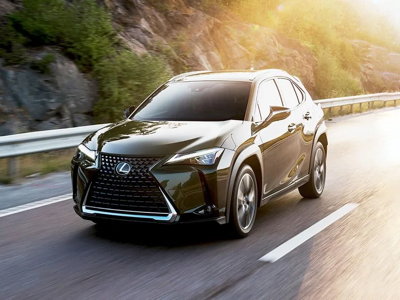

Make: Lexus
Model: UX
Approximate year / generation: 2019–present (1st Generation, ZA10)
Confidence: High
Notes: The vehicle features Lexus's signature spindle grille, sharp arrowhead DRLs, and unique squared-off wheel arch cladding specific to the compact UX crossover, shown here in Nori Green Pearl.


In [22]:
# 4. Try it out — change this to the path of your own photo
IMAGE_PATH = "car2.webp"

display(Image.open(IMAGE_PATH).resize((400, 300)))

result = identify_car(IMAGE_PATH)
print(result)